# Final Project Heart Attack Classification by PatternSeeker

## Import Library

In [47]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression # langsung pilih satu algoritma klasifikasi saja
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, precision_score, f1_score 
import pickle

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

## Import Data

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/Pattern-Seeker/heart-attack-classification/refs/heads/main/heart_attack_prediction_dataset.csv')
df

,Patient ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
0,BMW7812,67,Male,208,158/88,72,0,0,1,0,0,4.168189,Average,0,0,9,6.615001,261404,31.251233,286,0,6,Argentina,South America,Southern Hemisphere,0
1,CZE1114,21,Male,389,165/93,98,1,1,1,1,1,1.813242,Unhealthy,1,0,1,4.963459,285768,27.194973,235,1,7,Canada,North America,Northern Hemisphere,0
2,BNI9906,21,Female,324,174/99,72,1,0,0,0,0,2.078353,Healthy,1,1,9,9.463426,235282,28.176571,587,4,4,France,Europe,Northern Hemisphere,0
3,JLN3497,84,Male,383,163/100,73,1,1,1,0,1,9.828130,Average,1,0,9,7.648981,125640,36.464704,378,3,4,Canada,North America,Northern Hemisphere,0
4,GFO8847,66,Male,318,91/88,93,1,1,1,1,0,5.804299,Unhealthy,1,0,6,1.514821,160555,21.809144,231,1,5,Thailand,Asia,Northern Hemisphere,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8758,MSV9918,60,Male,121,94/76,61,1,1,1,0,1,7.917342,Healthy,1,1,8,10.806373,235420,19.655895,67,7,7,Thailand,Asia,Northern Hemisphere,0
8759,QSV6764,28,Female,120,157/102,73,1,0,0,1,0,16.558426,Healthy,0,0,8,3.833038,217881,23.993866,617,4,9,Canada,North America,Northern Hemisphere,0
8760,XKA5925,47,Male,250,161/75,105,0,1,1,1,1,3.148438,Average,1,0,5,2.375214,36998,35.406146,527,4,4,Brazil,South America,Southern Hemisphere,1
8761,EPE6801,36,Male,178,119/67,60,1,0,1,0,0,3.789950,Unhealthy,1,1,5,0.029104,209943,27.294020,114,2,8,Brazil,South America,Southern Hemisphere,0


## 1.&nbsp;Data Preprocessing

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Patient ID                       8763 non-null   object 
 1   Age                              8763 non-null   int64  
 2   Sex                              8763 non-null   object 
 3   Cholesterol                      8763 non-null   int64  
 4   Blood Pressure                   8763 non-null   object 
 5   Heart Rate                       8763 non-null   int64  
 6   Diabetes                         8763 non-null   int64  
 7   Family History                   8763 non-null   int64  
 8   Smoking                          8763 non-null   int64  
 9   Obesity                          8763 non-null   int64  
 10  Alcohol Consumption              8763 non-null   int64  
 11  Exercise Hours Per Week          8763 non-null   float64
 12  Diet                

In [4]:
df.shape

(8763, 26)

### a.&nbsp;Drop Null

In [5]:
df = df.dropna() # hapus semua baris yg ada null-nya
df

,Patient ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
0,BMW7812,67,Male,208,158/88,72,0,0,1,0,0,4.168189,Average,0,0,9,6.615001,261404,31.251233,286,0,6,Argentina,South America,Southern Hemisphere,0
1,CZE1114,21,Male,389,165/93,98,1,1,1,1,1,1.813242,Unhealthy,1,0,1,4.963459,285768,27.194973,235,1,7,Canada,North America,Northern Hemisphere,0
2,BNI9906,21,Female,324,174/99,72,1,0,0,0,0,2.078353,Healthy,1,1,9,9.463426,235282,28.176571,587,4,4,France,Europe,Northern Hemisphere,0
3,JLN3497,84,Male,383,163/100,73,1,1,1,0,1,9.828130,Average,1,0,9,7.648981,125640,36.464704,378,3,4,Canada,North America,Northern Hemisphere,0
4,GFO8847,66,Male,318,91/88,93,1,1,1,1,0,5.804299,Unhealthy,1,0,6,1.514821,160555,21.809144,231,1,5,Thailand,Asia,Northern Hemisphere,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8758,MSV9918,60,Male,121,94/76,61,1,1,1,0,1,7.917342,Healthy,1,1,8,10.806373,235420,19.655895,67,7,7,Thailand,Asia,Northern Hemisphere,0
8759,QSV6764,28,Female,120,157/102,73,1,0,0,1,0,16.558426,Healthy,0,0,8,3.833038,217881,23.993866,617,4,9,Canada,North America,Northern Hemisphere,0
8760,XKA5925,47,Male,250,161/75,105,0,1,1,1,1,3.148438,Average,1,0,5,2.375214,36998,35.406146,527,4,4,Brazil,South America,Southern Hemisphere,1
8761,EPE6801,36,Male,178,119/67,60,1,0,1,0,0,3.789950,Unhealthy,1,1,5,0.029104,209943,27.294020,114,2,8,Brazil,South America,Southern Hemisphere,0


In [6]:
df['Sex'].value_counts()  # imbalanced dataset, ada kelas mayoritas (Sex = Male), ada kelas minoritas (Sex = Female)

Sex
Male      6111
Female    2652
Name: count, dtype: int64

In [7]:
df['Family History'].value_counts()

Family History
0    4443
1    4320
Name: count, dtype: int64

In [8]:
df['Smoking'].value_counts() # imbalanced dataset, ada kelas mayoritas (Smoking = 1), ada kelas minoritas (Smoking = 0)

Smoking
1    7859
0     904
Name: count, dtype: int64

In [9]:
df['Diabetes'].value_counts()

Diabetes
1    5716
0    3047
Name: count, dtype: int64

In [10]:
df['Obesity'].value_counts()

Obesity
1    4394
0    4369
Name: count, dtype: int64

In [11]:
df['Diet'].value_counts()

Diet
Healthy      2960
Average      2912
Unhealthy    2891
Name: count, dtype: int64

In [12]:
df['Stress Level'].value_counts()

Stress Level
2     913
4     910
7     903
9     887
8     879
3     868
1     865
5     860
6     855
10    823
Name: count, dtype: int64

In [13]:
df['Country'].value_counts()

Country
Germany           477
Argentina         471
Brazil            462
United Kingdom    457
Australia         449
Nigeria           448
France            446
Canada            440
China             436
New Zealand       435
Japan             433
Italy             431
Spain             430
Colombia          429
Thailand          428
South Africa      425
Vietnam           425
United States     420
India             412
South Korea       409
Name: count, dtype: int64

In [14]:
df['Continent'].value_counts()

Continent
Asia             2543
Europe           2241
South America    1362
Australia         884
Africa            873
North America     860
Name: count, dtype: int64

In [15]:
df['Hemisphere'].value_counts()

Hemisphere
Northern Hemisphere    5660
Southern Hemisphere    3103
Name: count, dtype: int64

In [16]:
df['Heart Attack Risk'].value_counts()

Heart Attack Risk
0    5624
1    3139
Name: count, dtype: int64

In [17]:
df_cp = df.copy()

In [18]:
df_cp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Patient ID                       8763 non-null   object 
 1   Age                              8763 non-null   int64  
 2   Sex                              8763 non-null   object 
 3   Cholesterol                      8763 non-null   int64  
 4   Blood Pressure                   8763 non-null   object 
 5   Heart Rate                       8763 non-null   int64  
 6   Diabetes                         8763 non-null   int64  
 7   Family History                   8763 non-null   int64  
 8   Smoking                          8763 non-null   int64  
 9   Obesity                          8763 non-null   int64  
 10  Alcohol Consumption              8763 non-null   int64  
 11  Exercise Hours Per Week          8763 non-null   float64
 12  Diet                

In [19]:
columns_cat = df_cp.select_dtypes(include = ['object']).columns.to_list()
columns_noncat = [col for col in df_cp.columns if col not in columns_cat]
columns_cat

['Patient ID',
 'Sex',
 'Blood Pressure',
 'Diet',
 'Country',
 'Continent',
 'Hemisphere']

In [20]:
columns_noncat

['Age',
 'Cholesterol',
 'Heart Rate',
 'Diabetes',
 'Family History',
 'Smoking',
 'Obesity',
 'Alcohol Consumption',
 'Exercise Hours Per Week',
 'Previous Heart Problems',
 'Medication Use',
 'Stress Level',
 'Sedentary Hours Per Day',
 'Income',
 'BMI',
 'Triglycerides',
 'Physical Activity Days Per Week',
 'Sleep Hours Per Day',
 'Heart Attack Risk']

### b.&nbsp;Encode Categorical Data (Label Encoding/One-Hot Encoding)

In [21]:
label_encoders = {} # dictionary untuk menyimpan objek encoder untuk setiap kolom kategorikal

for col in columns_cat:
  label_encoder = LabelEncoder() # membuat objek label encoder BARU
  label_encoder.fit(df_cp[col])
  df_cp[col] = label_encoder.transform(df_cp[col])
  label_encoders[col] = label_encoder
  # pickle.dump(label_encoder, open('label_encoder_'+col+'.pkl', 'wb'))

### c. plotting

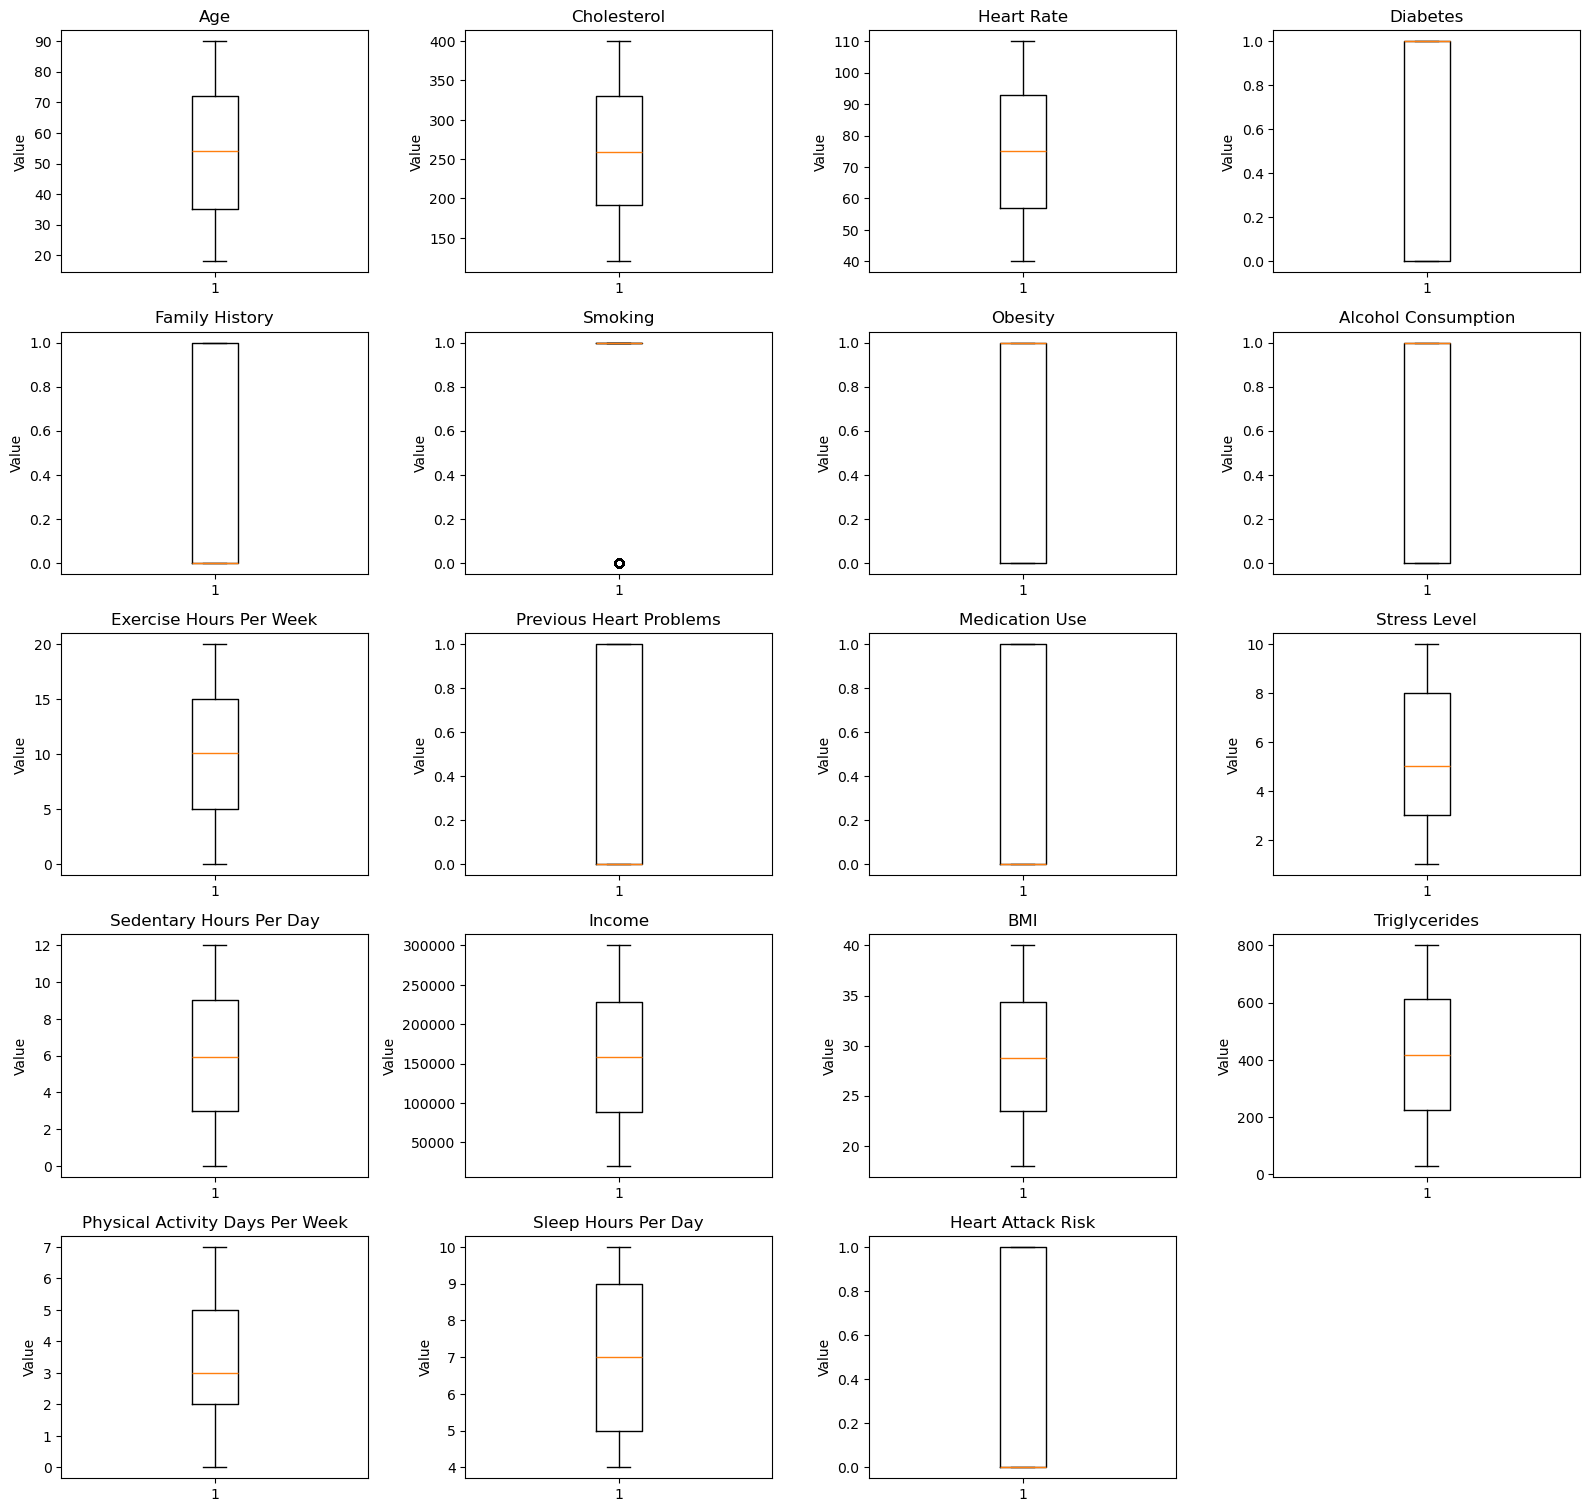

In [22]:
import matplotlib.pyplot as plt

# Get all non-categorical columns
numeric_cols = columns_noncat

# Create boxplots for all numeric columns
fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(16, 18))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    axes[idx].boxplot(df_cp[col])
    axes[idx].set_title(col)
    axes[idx].set_ylabel('Value')

# Hide unused subplots
for idx in range(len(numeric_cols), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

## Modelling
 

In [23]:
df_cp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Patient ID                       8763 non-null   int64  
 1   Age                              8763 non-null   int64  
 2   Sex                              8763 non-null   int64  
 3   Cholesterol                      8763 non-null   int64  
 4   Blood Pressure                   8763 non-null   int64  
 5   Heart Rate                       8763 non-null   int64  
 6   Diabetes                         8763 non-null   int64  
 7   Family History                   8763 non-null   int64  
 8   Smoking                          8763 non-null   int64  
 9   Obesity                          8763 non-null   int64  
 10  Alcohol Consumption              8763 non-null   int64  
 11  Exercise Hours Per Week          8763 non-null   float64
 12  Diet                

In [24]:
# === Modelling: Logistic Regression, Random Forest, SVM, KNN, XGBoost ===
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score

# XGBoost optional
try:
    from xgboost import XGBClassifier
    xgb_available = True
except Exception:
    XGBClassifier = None
    xgb_available = False
    print("Warning: xgboost tidak terpasang. Untuk memakai XGBoost jalankan: pip install xgboost")

# Siapkan fitur dan target
target = 'Heart Attack Risk'
if target not in df_cp.columns:
    raise KeyError(f"Kolom target '{target}' tidak ditemukan di dataset. Periksa nama kolom di df_cp.")

X = df_cp.drop(columns=[target])
y = df_cp[target]

X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=32, stratify=y)


# Definisikan model (scaling untuk algoritma yang sensitif)
models = {
    'LogisticRegression': Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000))]),
    'RandomForest': Pipeline([('clf', RandomForestClassifier(random_state=32))]),
    'SVM': Pipeline([('scaler', StandardScaler()), ('clf', SVC(probability=True, random_state=32))]),
    'KNN': Pipeline([('scaler', StandardScaler()), ('clf', KNeighborsClassifier())])
}
if xgb_available:
    models['XGBoost'] = Pipeline([('clf', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=32))])

# Training dan evaluasi
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    cr = classification_report(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    try:
        y_proba = model.predict_proba(X_test)[:, 1]
        roc = roc_auc_score(y_test, y_proba)
    except Exception:
        roc = None

    print(f"--- {name} ---")
    print(cr)
    print('Accuracy:', acc)
    if roc is not None:
        print('ROC AUC:', roc)
    print('Confusion Matrix:\n', cm)
    print('\n')

    # simpan model individual
    pickle.dump(model, open(f'model_{name}.pkl', 'wb'))

    results.append({'name': name, 'model': model, 'accuracy': acc, 'roc_auc': roc})

# Ringkasan
summary_df = pd.DataFrame(results)[['name','accuracy','roc_auc']].sort_values(by='accuracy', ascending=False).reset_index(drop=True)
print('Ringkasan performa:')
display(summary_df)

# Simpan model terbaik (berdasarkan accuracy)
best = max(results, key=lambda x: x['accuracy'])
print('Best model:', best['name'], 'accuracy:', best['accuracy'])
pickle.dump(best['model'], open('model_best.pkl', 'wb'))

--- LogisticRegression ---
              precision    recall  f1-score   support

           0       0.64      1.00      0.78      1687
           1       0.00      0.00      0.00       942

    accuracy                           0.64      2629
   macro avg       0.32      0.50      0.39      2629
weighted avg       0.41      0.64      0.50      2629

Accuracy: 0.6416888550779765
ROC AUC: 0.4969486909387007
Confusion Matrix:
 [[1687    0]
 [ 942    0]]


--- RandomForest ---
              precision    recall  f1-score   support

           0       0.64      0.98      0.77      1687
           1       0.35      0.02      0.04       942

    accuracy                           0.63      2629
   macro avg       0.50      0.50      0.41      2629
weighted avg       0.54      0.63      0.51      2629

Accuracy: 0.6344617725370864
ROC AUC: 0.5109363220933905
Confusion Matrix:
 [[1646   41]
 [ 920   22]]


--- SVM ---
              precision    recall  f1-score   support

           0       0.

  File "c:\Users\ishid\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\ishid\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\ishid\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\ishid\anaconda3\Lib\subprocess.

--- XGBoost ---
              precision    recall  f1-score   support

           0       0.64      0.80      0.71      1687
           1       0.35      0.19      0.25       942

    accuracy                           0.58      2629
   macro avg       0.50      0.50      0.48      2629
weighted avg       0.54      0.58      0.55      2629

Accuracy: 0.5831114492202358
ROC AUC: 0.5112242111211374
Confusion Matrix:
 [[1351  336]
 [ 760  182]]


Ringkasan performa:


,name,accuracy,roc_auc
0,LogisticRegression,0.641689,0.496949
1,SVM,0.641308,0.505376
2,RandomForest,0.634462,0.510936
3,XGBoost,0.583111,0.511224
4,KNN,0.549639,0.472308


Best model: LogisticRegression accuracy: 0.6416888550779765


In [25]:
# === IMPORT ===
import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# === XGBOOST (OPSIONAL) ===
try:
    from xgboost import XGBClassifier
    xgb_available = True
except:
    xgb_available = False

# === DATA ===
target = 'Heart Attack Risk'
X = df_cp.drop(columns=[target]).reset_index(drop=True)
y = df_cp[target].reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=32, stratify=y
)

# === MODEL ===
models = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000))
    ]),
    'RandomForest': Pipeline([
        ('clf', RandomForestClassifier(random_state=32))
    ]),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(probability=True, random_state=32))
    ]),
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier())
    ])
}

if xgb_available:
    models['XGBoost'] = Pipeline([
        ('clf', XGBClassifier(
            eval_metric='logloss',
            use_label_encoder=False,
            random_state=32
        ))
    ])

# === TRAIN & EVALUATE ===
results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')

    try:
        y_proba = model.predict_proba(X_test)[:, 1]
        roc = roc_auc_score(y_test, y_proba)
    except:
        roc = None

    print(f"\n===== {name} =====")
    print("Accuracy :", acc)
    print("F1-score :", f1)
    if roc:
        print("ROC AUC  :", roc)
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

    results.append({
        'Model': name,
        'Accuracy': acc,
        'F1_score': f1,
        'ROC_AUC': roc
    })

# === RINGKASAN ===
summary = pd.DataFrame(results).sort_values(
    by='F1_score', ascending=False
).reset_index(drop=True)

print("\n📊 PERBANDINGAN MODEL (berdasarkan F1-score)")
display(summary)



===== LogisticRegression =====
Accuracy : 0.6416888550779765
F1-score : 0.39087117701575536
ROC AUC  : 0.4969486909387007
Confusion Matrix:
 [[1687    0]
 [ 942    0]]

===== RandomForest =====
Accuracy : 0.6344617725370864
F1-score : 0.4089114736685723
ROC AUC  : 0.5109363220933905
Confusion Matrix:
 [[1646   41]
 [ 920   22]]

===== SVM =====
Accuracy : 0.6413084823126665
F1-score : 0.39274055686724635
ROC AUC  : 0.5053758163148443
Confusion Matrix:
 [[1684    3]
 [ 940    2]]

===== KNN =====
Accuracy : 0.5496386458729555
F1-score : 0.4722022140561775
ROC AUC  : 0.47230759259329186
Confusion Matrix:
 [[1226  461]
 [ 723  219]]

===== XGBoost =====
Accuracy : 0.5831114492202358
F1-score : 0.48037106768522725
ROC AUC  : 0.5112242111211374
Confusion Matrix:
 [[1351  336]
 [ 760  182]]

📊 PERBANDINGAN MODEL (berdasarkan F1-score)


,Model,Accuracy,F1_score,ROC_AUC
0,XGBoost,0.583111,0.480371,0.511224
1,KNN,0.549639,0.472202,0.472308
2,RandomForest,0.634462,0.408911,0.510936
3,SVM,0.641308,0.392741,0.505376
4,LogisticRegression,0.641689,0.390871,0.496949


## Evaluation

In [26]:
# === IMPORT ===
import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE, SMOTENC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# === XGBOOST (OPSIONAL) ===
try:
    from xgboost import XGBClassifier
    xgb_available = True
except:
    xgb_available = False

### Feature Engineering

In [27]:
# Separate 'Blood Pressure' column into 'Sistole' and 'Diastole'
df_cp[['Sistole', 'Diastole']] = df['Blood Pressure'].str.split('/', expand=True).astype(int)
df_cp.head()

,Patient ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk,Sistole,Diastole
0,521,67,1,208,2510,72,0,0,1,0,0,4.168189,0,0,0,9,6.615001,261404,31.251233,286,0,6,0,5,1,0,158,88
1,998,21,1,389,2815,98,1,1,1,1,1,1.813242,2,1,0,1,4.963459,285768,27.194973,235,1,7,3,4,0,0,165,93
2,529,21,0,324,3224,72,1,0,0,0,0,2.078353,1,1,1,9,9.463426,235282,28.176571,587,4,4,6,3,0,0,174,99
3,3160,84,1,383,2689,73,1,1,1,0,1,9.828130,0,1,0,9,7.648981,125640,36.464704,378,3,4,3,4,0,0,163,100
4,2083,66,1,318,3563,93,1,1,1,1,0,5.804299,2,1,0,6,1.514821,160555,21.809144,231,1,5,16,1,0,0,91,88


In [28]:
df_cp_2 = pd.get_dummies(df, columns=['Continent'], dtype=int)

for col in df['Continent'].unique().tolist():
    df_cp[f'Continent_{col}'] = df_cp_2[f'Continent_{col}']

df_cp.head()

,Patient ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk,Sistole,Diastole,Continent_South America,Continent_North America,Continent_Europe,Continent_Asia,Continent_Africa,Continent_Australia
0,521,67,1,208,2510,72,0,0,1,0,0,4.168189,0,0,0,9,6.615001,261404,31.251233,286,0,6,0,5,1,0,158,88,1,0,0,0,0,0
1,998,21,1,389,2815,98,1,1,1,1,1,1.813242,2,1,0,1,4.963459,285768,27.194973,235,1,7,3,4,0,0,165,93,0,1,0,0,0,0
2,529,21,0,324,3224,72,1,0,0,0,0,2.078353,1,1,1,9,9.463426,235282,28.176571,587,4,4,6,3,0,0,174,99,0,0,1,0,0,0
3,3160,84,1,383,2689,73,1,1,1,0,1,9.828130,0,1,0,9,7.648981,125640,36.464704,378,3,4,3,4,0,0,163,100,0,1,0,0,0,0
4,2083,66,1,318,3563,93,1,1,1,1,0,5.804299,2,1,0,6,1.514821,160555,21.809144,231,1,5,16,1,0,0,91,88,0,0,0,1,0,0


### Measuring Correlation of Feature to target

#### Numerical features

In [29]:
df.head()

,Patient ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
0,BMW7812,67,Male,208,158/88,72,0,0,1,0,0,4.168189,Average,0,0,9,6.615001,261404,31.251233,286,0,6,Argentina,South America,Southern Hemisphere,0
1,CZE1114,21,Male,389,165/93,98,1,1,1,1,1,1.813242,Unhealthy,1,0,1,4.963459,285768,27.194973,235,1,7,Canada,North America,Northern Hemisphere,0
2,BNI9906,21,Female,324,174/99,72,1,0,0,0,0,2.078353,Healthy,1,1,9,9.463426,235282,28.176571,587,4,4,France,Europe,Northern Hemisphere,0
3,JLN3497,84,Male,383,163/100,73,1,1,1,0,1,9.828130,Average,1,0,9,7.648981,125640,36.464704,378,3,4,Canada,North America,Northern Hemisphere,0
4,GFO8847,66,Male,318,91/88,93,1,1,1,1,0,5.804299,Unhealthy,1,0,6,1.514821,160555,21.809144,231,1,5,Thailand,Asia,Northern Hemisphere,0


In [30]:
df.columns

Index(['Patient ID', 'Age', 'Sex', 'Cholesterol', 'Blood Pressure',
       'Heart Rate', 'Diabetes', 'Family History', 'Smoking', 'Obesity',
       'Alcohol Consumption', 'Exercise Hours Per Week', 'Diet',
       'Previous Heart Problems', 'Medication Use', 'Stress Level',
       'Sedentary Hours Per Day', 'Income', 'BMI', 'Triglycerides',
       'Physical Activity Days Per Week', 'Sleep Hours Per Day', 'Country',
       'Continent', 'Hemisphere', 'Heart Attack Risk'],
      dtype='object')

In [31]:
target_col = 'Heart Attack Risk'
numerical_col = ['Age', 'Cholesterol', 'Heart Rate', 'Exercise Hours Per Week', 'Sedentary Hours Per Day', 'Income', 'BMI', 'Triglycerides',
       'Physical Activity Days Per Week', 'Sleep Hours Per Day', 'Sistole', 'Diastole'] 

Point-Biserial Correlation with Target:
                                 correlation   p_value
Cholesterol                         0.019340  0.070247
Sistole                             0.018585  0.081915
Exercise Hours Per Week             0.011133  0.297394
Triglycerides                       0.010471  0.327022
Income                              0.009628  0.367513
Age                                 0.006403  0.548954
BMI                                 0.000020  0.998486
Heart Rate                         -0.004251  0.690701
Physical Activity Days Per Week    -0.005014  0.638887
Sedentary Hours Per Day            -0.005613  0.599330
Diastole                           -0.007509  0.482148
Sleep Hours Per Day                -0.018528  0.082857


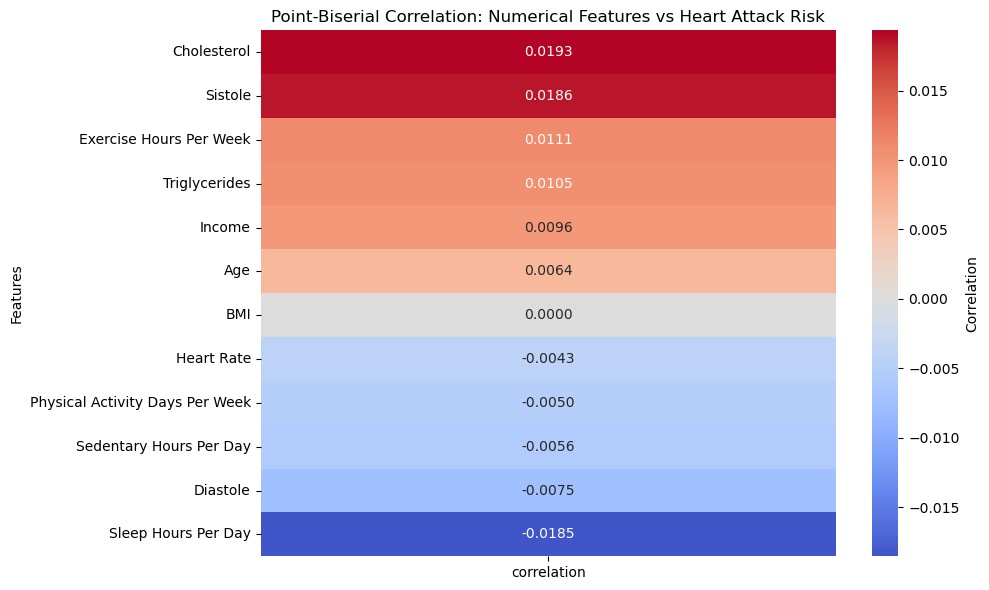

In [32]:
from scipy.stats import pointbiserialr
import seaborn as sns

import matplotlib.pyplot as plt

# Calculate Point-Biserial Correlation for numerical features with target
point_biserial_corr = {}

for col in numerical_col:
    corr, p_value = pointbiserialr(df_cp[target_col], df_cp[col])
    point_biserial_corr[col] = {'correlation': corr, 'p_value': p_value}

# Convert to DataFrame for better visualization
pb_corr_df = pd.DataFrame(point_biserial_corr).T.sort_values(by='correlation', ascending=False)
print("Point-Biserial Correlation with Target:")
print(pb_corr_df)

# Create heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pb_corr_df[['correlation']], annot=True, cmap='coolwarm', center=0, 
            cbar_kws={'label': 'Correlation'}, fmt='.4f')
plt.title('Point-Biserial Correlation: Numerical Features vs Heart Attack Risk')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

#### Categorical Features

In [33]:
df.head()

,Patient ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
0,BMW7812,67,Male,208,158/88,72,0,0,1,0,0,4.168189,Average,0,0,9,6.615001,261404,31.251233,286,0,6,Argentina,South America,Southern Hemisphere,0
1,CZE1114,21,Male,389,165/93,98,1,1,1,1,1,1.813242,Unhealthy,1,0,1,4.963459,285768,27.194973,235,1,7,Canada,North America,Northern Hemisphere,0
2,BNI9906,21,Female,324,174/99,72,1,0,0,0,0,2.078353,Healthy,1,1,9,9.463426,235282,28.176571,587,4,4,France,Europe,Northern Hemisphere,0
3,JLN3497,84,Male,383,163/100,73,1,1,1,0,1,9.828130,Average,1,0,9,7.648981,125640,36.464704,378,3,4,Canada,North America,Northern Hemisphere,0
4,GFO8847,66,Male,318,91/88,93,1,1,1,1,0,5.804299,Unhealthy,1,0,6,1.514821,160555,21.809144,231,1,5,Thailand,Asia,Northern Hemisphere,0


In [34]:
df_cp.head()

,Patient ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk,Sistole,Diastole,Continent_South America,Continent_North America,Continent_Europe,Continent_Asia,Continent_Africa,Continent_Australia
0,521,67,1,208,2510,72,0,0,1,0,0,4.168189,0,0,0,9,6.615001,261404,31.251233,286,0,6,0,5,1,0,158,88,1,0,0,0,0,0
1,998,21,1,389,2815,98,1,1,1,1,1,1.813242,2,1,0,1,4.963459,285768,27.194973,235,1,7,3,4,0,0,165,93,0,1,0,0,0,0
2,529,21,0,324,3224,72,1,0,0,0,0,2.078353,1,1,1,9,9.463426,235282,28.176571,587,4,4,6,3,0,0,174,99,0,0,1,0,0,0
3,3160,84,1,383,2689,73,1,1,1,0,1,9.828130,0,1,0,9,7.648981,125640,36.464704,378,3,4,3,4,0,0,163,100,0,1,0,0,0,0
4,2083,66,1,318,3563,93,1,1,1,1,0,5.804299,2,1,0,6,1.514821,160555,21.809144,231,1,5,16,1,0,0,91,88,0,0,0,1,0,0


In [35]:
df['Stress Level'].value_counts()

Stress Level
2     913
4     910
7     903
9     887
8     879
3     868
1     865
5     860
6     855
10    823
Name: count, dtype: int64

In [36]:
categ_col = [col for col in df_cp.columns if col not in numerical_col + ['Patient ID', 'Heart Attack Risk']]
ordinal_col = ['Diet', 'Stress Level']
nominal_col = [col for col in categ_col if col not in ordinal_col]
nominal_col

['Sex',
 'Blood Pressure',
 'Diabetes',
 'Family History',
 'Smoking',
 'Obesity',
 'Alcohol Consumption',
 'Previous Heart Problems',
 'Medication Use',
 'Country',
 'Continent',
 'Hemisphere',
 'Continent_South America',
 'Continent_North America',
 'Continent_Europe',
 'Continent_Asia',
 'Continent_Africa',
 'Continent_Australia']

Cramér's V Association Strength with Target:
                    Feature  Cramers_V
1            Blood Pressure   0.665731
9                   Country   0.048131
10                Continent   0.020920
2                  Diabetes   0.016975
14         Continent_Europe   0.014866
6       Alcohol Consumption   0.013535
5                   Obesity   0.013080
11               Hemisphere   0.012455
13  Continent_North America   0.012351
16         Continent_Africa   0.006979
12  Continent_South America   0.006974
15           Continent_Asia   0.005469
4                   Smoking   0.003660
0                       Sex   0.002836
8            Medication Use   0.001996
17      Continent_Australia   0.001455
3            Family History   0.001414
7   Previous Heart Problems   0.000036


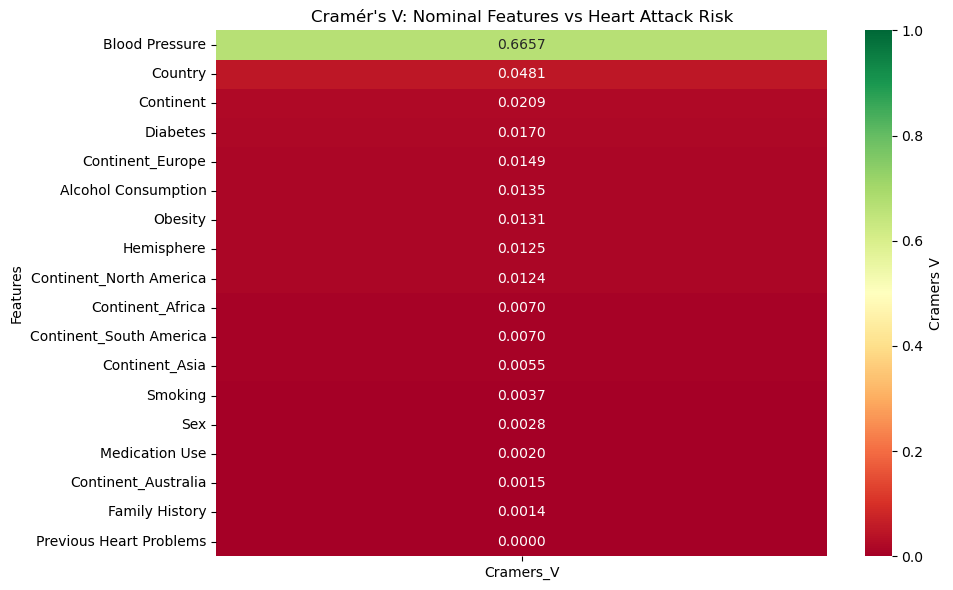

In [37]:
from scipy.stats import chi2_contingency
import numpy as np

def cramers_v(x, y):
    """Calculate Cramér's V statistic for categorical-categorical association."""
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    min_dim = min(confusion_matrix.shape) - 1
    return np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0

# Calculate Cramér's V for nominal features with target
cramers_v_results = {}

for col in nominal_col:
    cv = cramers_v(df_cp[col], df_cp[target_col])
    cramers_v_results[col] = cv

# Convert to DataFrame for better visualization
cramers_df = pd.DataFrame(list(cramers_v_results.items()), 
                          columns=['Feature', 'Cramers_V']).sort_values(by='Cramers_V', 
                                                                         ascending=False)

print("Cramér's V Association Strength with Target:")
print(cramers_df)

# Create heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(cramers_df.set_index('Feature')[['Cramers_V']], 
            annot=True, cmap='RdYlGn', vmin=0, vmax=1,
            cbar_kws={'label': 'Cramers V'}, fmt='.4f')
plt.title('Cramér\'s V: Nominal Features vs Heart Attack Risk')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

Kendall's Tau Correlation with Target:
              correlation   p_value
Diet             0.004289  0.670201
Stress Level    -0.003524  0.700071


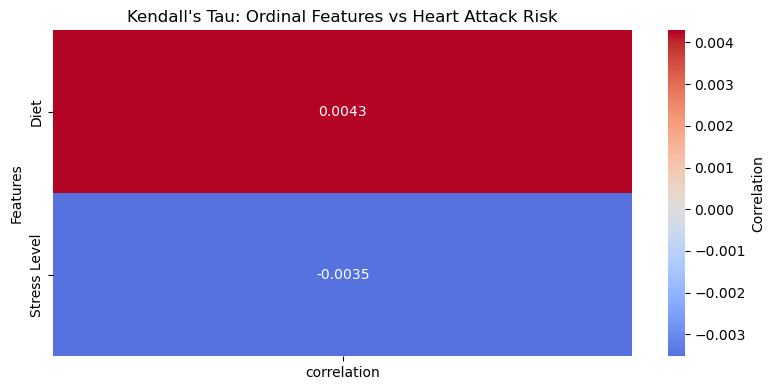

In [38]:
from scipy.stats import kendalltau

# Calculate Kendall's Tau correlation for ordinal features with target
kendall_results = {}

for col in ordinal_col:
    corr, p_value = kendalltau(df_cp[col], df_cp[target_col])
    kendall_results[col] = {'correlation': corr, 'p_value': p_value}

# Convert to DataFrame for better visualization
kendall_df = pd.DataFrame(kendall_results).T.sort_values(by='correlation', ascending=False)
print("Kendall's Tau Correlation with Target:")
print(kendall_df)

# Create heatmap
plt.figure(figsize=(8, 4))
sns.heatmap(kendall_df[['correlation']], annot=True, cmap='coolwarm', center=0, 
            cbar_kws={'label': 'Correlation'}, fmt='.4f')
plt.title("Kendall's Tau: Ordinal Features vs Heart Attack Risk")
plt.ylabel('Features')
plt.tight_layout()
plt.show()

### Modelling


In [40]:
df_cp.columns

Index(['Patient ID', 'Age', 'Sex', 'Cholesterol', 'Blood Pressure',
       'Heart Rate', 'Diabetes', 'Family History', 'Smoking', 'Obesity',
       'Alcohol Consumption', 'Exercise Hours Per Week', 'Diet',
       'Previous Heart Problems', 'Medication Use', 'Stress Level',
       'Sedentary Hours Per Day', 'Income', 'BMI', 'Triglycerides',
       'Physical Activity Days Per Week', 'Sleep Hours Per Day', 'Country',
       'Continent', 'Hemisphere', 'Heart Attack Risk', 'Sistole', 'Diastole',
       'Continent_South America', 'Continent_North America',
       'Continent_Europe', 'Continent_Asia', 'Continent_Africa',
       'Continent_Australia'],
      dtype='object')

In [41]:
target = 'Heart Attack Risk'
X = df_cp.drop(columns=[target, 'Patient ID', 'Previous Heart Problems', 'BMI']).reset_index(drop=True)
y = df_cp[target].reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=32, stratify=y
)

In [48]:
# === MODEL ===
models = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000))
    ]),
    'RandomForest': Pipeline([
        ('clf', RandomForestClassifier(random_state=32))
    ]),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(probability=True, random_state=32))
    ]),
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier())
    ])
}

if xgb_available:
    models['XGBoost'] = Pipeline([
        ('clf', XGBClassifier(
            eval_metric='logloss',
            use_label_encoder=False,
            random_state=32
        ))
    ])


In [50]:
# === TRAIN & EVALUATE ===

results = []
for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')

    try:
        y_proba = model.predict_proba(X_test)[:, 1]
        roc = roc_auc_score(y_test, y_proba)
    except:
        roc = None

    print(f"\n===== {name} =====")
    print("Accuracy :", acc)
    print("F1-score :", f1)
    print("Precision :", prec)
    if roc:
        print("ROC AUC  :", roc)
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'F1_score': f1,
        'ROC_AUC': roc
    })

# === RINGKASAN ===
summary = pd.DataFrame(results).sort_values(
    by='F1_score', ascending=False
).reset_index(drop=True)

print("\n📊 PERBANDINGAN MODEL (berdasarkan F1-score)")
display(summary)


===== LogisticRegression =====
Accuracy : 0.6416888550779765
F1-score : 0.39087117701575536
Precision : 0.32084442753898823
ROC AUC  : 0.5141219793676384
Confusion Matrix:
 [[1687    0]
 [ 942    0]]

===== RandomForest =====
Accuracy : 0.6359832635983264
F1-score : 0.40501471291778335
Precision : 0.49420582186362916
ROC AUC  : 0.5044054887065696
Confusion Matrix:
 [[1655   32]
 [ 925   17]]

===== SVM =====
Accuracy : 0.6405477367820464
F1-score : 0.3904474843496406
Precision : 0.32063975628332064
ROC AUC  : 0.5062322468432889
Confusion Matrix:
 [[1684    3]
 [ 942    0]]

===== KNN =====
Accuracy : 0.5538227462913655
F1-score : 0.4779948395610631
Precision : 0.4817942537022018
ROC AUC  : 0.4912982001744324
Confusion Matrix:
 [[1229  458]
 [ 715  227]]

===== XGBoost =====
Accuracy : 0.5884366679345758
F1-score : 0.4887273263212383
Precision : 0.5053811411906582
ROC AUC  : 0.515958176488874
Confusion Matrix:
 [[1354  333]
 [ 749  193]]

📊 PERBANDINGAN MODEL (berdasarkan F1-score)


,Model,Accuracy,Precision,F1_score,ROC_AUC
0,XGBoost,0.588437,0.505381,0.488727,0.515958
1,KNN,0.553823,0.481794,0.477995,0.491298
2,RandomForest,0.635983,0.494206,0.405015,0.504405
3,LogisticRegression,0.641689,0.320844,0.390871,0.514122
4,SVM,0.640548,0.320640,0.390447,0.506232


### Hyperparameter Tuning

#### F1_Score

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define hyperparameter grids for each model
param_grids = {
    'LogisticRegression': {
        'clf__C': [0.1, 1, 10],
        'clf__solver': ['lbfgs', 'liblinear', 'saga'],
        'clf__penalty': ['l1', 'l2', 'elasticnet']
    },
    'RandomForest': {
        'clf__n_estimators': [50, 100, 200],
        'clf__max_depth': [5, 10, 20, None],
        'clf__min_samples_split': [2, 5],
        'clf__max_features': ['sqrt', 'log2', None]
    },
    'SVM': {
        'clf__C': [0.1, 1, 10],
        'clf__kernel': ['linear', 'rbf'],
        'clf__gamma': ['scale', 'auto']
    },
    'KNN': {
        'clf__n_neighbors': [3, 5, 7, 9],
        'clf__weights': ['uniform', 'distance']
    }
}

if xgb_available:
    param_grids['XGBoost'] = {
        'clf__n_estimators': [50, 100, 200],
        'clf__max_depth': [3, 5, 7],
        'clf__learning_rate': [0.01, 0.05, 0.1],
        'clf__subsample': [0.8, 1.0]
    }

# GridSearchCV for each model
best_models = {}
for name, model in models.items():
    print(f"\n🔍 Tuning {name}...")
    grid_search = GridSearchCV(
        model, 
        param_grids[name], 
        cv=5, 
        scoring='f1_macro', 
        n_jobs=-1
    )
    grid_search.fit(X_train, y_train)
    
    best_models[name] = grid_search.best_estimator_
    print(f"✅ Best params: {grid_search.best_params_}")
    print(f"   Best CV score: {grid_search.best_score_:.4f}")

# Evaluate tuned models
tuned_results = []
for name, best_model in best_models.items():
    y_pred = best_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    
    try:
        y_proba = best_model.predict_proba(X_test)[:, 1]
        roc = roc_auc_score(y_test, y_proba)
    except:
        roc = None
    
    tuned_results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision' : prec,
        'F1_score': f1,
        'ROC_AUC': roc
    })

# Summary of tuned models
tuned_summary = pd.DataFrame(tuned_results).sort_values(
    by='F1_score', ascending=False
).reset_index(drop=True)

print("\n📊 TUNED MODELS COMPARISON")
display(tuned_summary)


🔍 Tuning LogisticRegression...
✅ Best params: {'clf__C': 0.1, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}
   Best CV score: 0.3909

🔍 Tuning RandomForest...
✅ Best params: {'clf__max_depth': 20, 'clf__max_features': None, 'clf__min_samples_split': 2, 'clf__n_estimators': 50}
   Best CV score: 0.4485

🔍 Tuning SVM...
✅ Best params: {'clf__C': 10, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
   Best CV score: 0.4901

🔍 Tuning KNN...
✅ Best params: {'clf__n_neighbors': 3, 'clf__weights': 'distance'}
   Best CV score: 0.4866

🔍 Tuning XGBoost...
✅ Best params: {'clf__learning_rate': 0.1, 'clf__max_depth': 5, 'clf__n_estimators': 200, 'clf__subsample': 0.8}
   Best CV score: 0.4717

📊 TUNED MODELS COMPARISON


,Model,Accuracy,Precision,F1_score,ROC_AUC
0,SVM,0.555344,0.496623,0.494514,0.500476
1,KNN,0.540129,0.479197,0.478154,0.482706
2,XGBoost,0.616204,0.520869,0.473701,0.513267
3,RandomForest,0.613922,0.474406,0.429773,0.502132
4,LogisticRegression,0.641689,0.320844,0.390871,0.509328


#### Precision

In [53]:
from sklearn.model_selection import GridSearchCV

# Define hyperparameter grids for each model
param_grids = {
    'LogisticRegression': {
        'clf__C': [0.1, 1, 10],
        'clf__solver': ['lbfgs', 'liblinear', 'saga'],
        'clf__penalty': ['l1', 'l2', 'elasticnet']
    },
    'RandomForest': {
        'clf__n_estimators': [50, 100, 200],
        'clf__max_depth': [5, 10, 20, None],
        'clf__min_samples_split': [2, 5],
        'clf__max_features': ['sqrt', 'log2', None]
    },
    'SVM': {
        'clf__C': [0.1, 1, 10],
        'clf__kernel': ['linear', 'rbf'],
        'clf__gamma': ['scale', 'auto']
    },
    'KNN': {
        'clf__n_neighbors': [3, 5, 7, 9],
        'clf__weights': ['uniform', 'distance']
    }
}

if xgb_available:
    param_grids['XGBoost'] = {
        'clf__n_estimators': [50, 100, 200],
        'clf__max_depth': [3, 5, 7],
        'clf__learning_rate': [0.01, 0.05, 0.1],
        'clf__subsample': [0.8, 1.0]
    }

# GridSearchCV for each model
best_models = {}
for name, model in models.items():
    print(f"\n🔍 Tuning {name}...")
    grid_search = GridSearchCV(
        model, 
        param_grids[name], 
        cv=5, 
        scoring='precision_macro', 
        n_jobs=-1
    )
    grid_search.fit(X_train, y_train)
    
    best_models[name] = grid_search.best_estimator_
    print(f"✅ Best params: {grid_search.best_params_}")
    print(f"   Best CV score: {grid_search.best_score_:.4f}")

# Evaluate tuned models
tuned_results = []
for name, best_model in best_models.items():
    y_pred = best_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    
    try:
        y_proba = best_model.predict_proba(X_test)[:, 1]
        roc = roc_auc_score(y_test, y_proba)
    except:
        roc = None
    
    tuned_results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision' : prec,
        'F1_score': f1,
        'ROC_AUC': roc
    })

# Summary of tuned models
tuned_summary = pd.DataFrame(tuned_results).sort_values(
    by='Precision', ascending=False
).reset_index(drop=True)

print("\n📊 TUNED MODELS COMPARISON")
display(tuned_summary)


🔍 Tuning LogisticRegression...
✅ Best params: {'clf__C': 0.1, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}
   Best CV score: 0.3209

🔍 Tuning RandomForest...
✅ Best params: {'clf__max_depth': 10, 'clf__max_features': 'log2', 'clf__min_samples_split': 5, 'clf__n_estimators': 100}
   Best CV score: 0.5711

🔍 Tuning SVM...
✅ Best params: {'clf__C': 10, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
   Best CV score: 0.4921

🔍 Tuning KNN...
✅ Best params: {'clf__n_neighbors': 7, 'clf__weights': 'distance'}
   Best CV score: 0.4955

🔍 Tuning XGBoost...
✅ Best params: {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 50, 'clf__subsample': 0.8}
   Best CV score: 0.5654

📊 TUNED MODELS COMPARISON


,Model,Accuracy,Precision,F1_score,ROC_AUC
0,XGBoost,0.641689,0.571006,0.393884,0.532443
1,SVM,0.555344,0.496623,0.494514,0.500476
2,KNN,0.571320,0.484533,0.474176,0.490288
3,LogisticRegression,0.641689,0.320844,0.390871,0.509318
4,RandomForest,0.641308,0.320776,0.390730,0.509582


#### ROC AUC

In [54]:
from sklearn.model_selection import GridSearchCV

# Define hyperparameter grids for each model
param_grids = {
    'LogisticRegression': {
        'clf__C': [0.1, 1, 10],
        'clf__solver': ['lbfgs', 'liblinear', 'saga'],
        'clf__penalty': ['l1', 'l2', 'elasticnet']
    },
    'RandomForest': {
        'clf__n_estimators': [50, 100, 200],
        'clf__max_depth': [5, 10, 20, None],
        'clf__min_samples_split': [2, 5],
        'clf__max_features': ['sqrt', 'log2', None]
    },
    'SVM': {
        'clf__C': [0.1, 1, 10],
        'clf__kernel': ['linear', 'rbf'],
        'clf__gamma': ['scale', 'auto']
    },
    'KNN': {
        'clf__n_neighbors': [3, 5, 7, 9],
        'clf__weights': ['uniform', 'distance']
    }
}

if xgb_available:
    param_grids['XGBoost'] = {
        'clf__n_estimators': [50, 100, 200],
        'clf__max_depth': [3, 5, 7],
        'clf__learning_rate': [0.01, 0.05, 0.1],
        'clf__subsample': [0.8, 1.0]
    }

# GridSearchCV for each model
best_models = {}
for name, model in models.items():
    print(f"\n🔍 Tuning {name}...")
    grid_search = GridSearchCV(
        model, 
        param_grids[name], 
        cv=5, 
        scoring='roc_auc', 
        n_jobs=-1
    )
    grid_search.fit(X_train, y_train)
    
    best_models[name] = grid_search.best_estimator_
    print(f"✅ Best params: {grid_search.best_params_}")
    print(f"   Best CV score: {grid_search.best_score_:.4f}")

# Evaluate tuned models
tuned_results = []
for name, best_model in best_models.items():
    y_pred = best_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    
    try:
        y_proba = best_model.predict_proba(X_test)[:, 1]
        roc = roc_auc_score(y_test, y_proba)
    except:
        roc = None
    
    tuned_results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision' : prec,
        'F1_score': f1,
        'ROC_AUC': roc
    })

# Summary of tuned models
tuned_summary = pd.DataFrame(tuned_results).sort_values(
    by='ROC_AUC', ascending=False
).reset_index(drop=True)

print("\n📊 TUNED MODELS COMPARISON")
display(tuned_summary)


🔍 Tuning LogisticRegression...
✅ Best params: {'clf__C': 10, 'clf__penalty': 'l1', 'clf__solver': 'saga'}
   Best CV score: 0.4848

🔍 Tuning RandomForest...
✅ Best params: {'clf__max_depth': 20, 'clf__max_features': 'sqrt', 'clf__min_samples_split': 5, 'clf__n_estimators': 100}
   Best CV score: 0.4939

🔍 Tuning SVM...
✅ Best params: {'clf__C': 0.1, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}
   Best CV score: 0.5072

🔍 Tuning KNN...
✅ Best params: {'clf__n_neighbors': 9, 'clf__weights': 'uniform'}
   Best CV score: 0.4892

🔍 Tuning XGBoost...
✅ Best params: {'clf__learning_rate': 0.1, 'clf__max_depth': 7, 'clf__n_estimators': 50, 'clf__subsample': 0.8}
   Best CV score: 0.4974

📊 TUNED MODELS COMPARISON


,Model,Accuracy,Precision,F1_score,ROC_AUC
0,XGBoost,0.625333,0.509319,0.439421,0.514357
1,LogisticRegression,0.641689,0.320844,0.390871,0.514119
2,RandomForest,0.640548,0.555121,0.410647,0.507318
3,SVM,0.641689,0.320844,0.390871,0.500666
4,KNN,0.588817,0.496802,0.477376,0.497860


#### Accuracy

In [55]:
from sklearn.model_selection import GridSearchCV

# Define hyperparameter grids for each model
param_grids = {
    'LogisticRegression': {
        'clf__C': [0.1, 1, 10],
        'clf__solver': ['lbfgs', 'liblinear', 'saga'],
        'clf__penalty': ['l1', 'l2', 'elasticnet']
    },
    'RandomForest': {
        'clf__n_estimators': [50, 100, 200],
        'clf__max_depth': [5, 10, 20, None],
        'clf__min_samples_split': [2, 5],
        'clf__max_features': ['sqrt', 'log2', None]
    },
    'SVM': {
        'clf__C': [0.1, 1, 10],
        'clf__kernel': ['linear', 'rbf'],
        'clf__gamma': ['scale', 'auto']
    },
    'KNN': {
        'clf__n_neighbors': [3, 5, 7, 9],
        'clf__weights': ['uniform', 'distance']
    }
}

if xgb_available:
    param_grids['XGBoost'] = {
        'clf__n_estimators': [50, 100, 200],
        'clf__max_depth': [3, 5, 7],
        'clf__learning_rate': [0.01, 0.05, 0.1],
        'clf__subsample': [0.8, 1.0]
    }

# GridSearchCV for each model
best_models = {}
for name, model in models.items():
    print(f"\n🔍 Tuning {name}...")
    grid_search = GridSearchCV(
        model, 
        param_grids[name], 
        cv=5, 
        scoring='accuracy', 
        n_jobs=-1
    )
    grid_search.fit(X_train, y_train)
    
    best_models[name] = grid_search.best_estimator_
    print(f"✅ Best params: {grid_search.best_params_}")
    print(f"   Best CV score: {grid_search.best_score_:.4f}")

# Evaluate tuned models
tuned_results = []
for name, best_model in best_models.items():
    y_pred = best_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    
    try:
        y_proba = best_model.predict_proba(X_test)[:, 1]
        roc = roc_auc_score(y_test, y_proba)
    except:
        roc = None
    
    tuned_results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision' : prec,
        'F1_score': f1,
        'ROC_AUC': roc
    })

# Summary of tuned models
tuned_summary = pd.DataFrame(tuned_results).sort_values(
    by='Accuracy', ascending=False
).reset_index(drop=True)

print("\n📊 TUNED MODELS COMPARISON")
display(tuned_summary)


🔍 Tuning LogisticRegression...
✅ Best params: {'clf__C': 0.1, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}
   Best CV score: 0.6418

🔍 Tuning RandomForest...
✅ Best params: {'clf__max_depth': 10, 'clf__max_features': 'log2', 'clf__min_samples_split': 5, 'clf__n_estimators': 100}
   Best CV score: 0.6423

🔍 Tuning SVM...
✅ Best params: {'clf__C': 0.1, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}
   Best CV score: 0.6418

🔍 Tuning KNN...
✅ Best params: {'clf__n_neighbors': 9, 'clf__weights': 'uniform'}
   Best CV score: 0.5872

🔍 Tuning XGBoost...
✅ Best params: {'clf__learning_rate': 0.01, 'clf__max_depth': 3, 'clf__n_estimators': 50, 'clf__subsample': 0.8}
   Best CV score: 0.6418

📊 TUNED MODELS COMPARISON


,Model,Accuracy,Precision,F1_score,ROC_AUC
0,LogisticRegression,0.641689,0.320844,0.390871,0.509311
1,SVM,0.641689,0.320844,0.390871,0.500666
2,XGBoost,0.641689,0.320844,0.390871,0.519921
3,RandomForest,0.641308,0.320776,0.390730,0.509582
4,KNN,0.588817,0.496802,0.477376,0.497860


# XX

## 3.&nbsp;Feature Selection

In [22]:
X = df_cp.drop(columns = ['Patient ID'])
y = df_cp['Heart Attack Risk']

In [23]:
X = X.reset_index(drop = True) # untuk mengurutkan kembali indeksnya
y = y.reset_index(drop = True)

## 4.&nbsp;Split Dataset

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 32)

## 5.&nbsp;Model Selection

In [25]:
logreg = LogisticRegression() # instansiasi objek LogisticRegression

## 6.&nbsp;Model Training

In [26]:
model_logreg = logreg.fit(X_train, y_train) #training, setelah selesai, kita dapatkan modelnya yaitu model_logreg

## 7.&nbsp;Model Evaluation

In [27]:
y_pred_train = model_logreg.predict(X_train)
y_pred_test = model_logreg.predict(X_test)

In [28]:
print('training accuracy: ', accuracy_score(y_train, y_pred_train))
print('testing accuracy: ', accuracy_score(y_test, y_pred_test))

training accuracy:  0.6475035663338089
testing accuracy:  0.6554478037649744


## 8.&nbsp;Model Deployment

In [29]:
pickle.dump(model_logreg, open('model_logreg.pkl', 'wb'))

In [30]:
!pip install Flask==3.0.0 pyngrok==7.1.2

  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached itsdangerous-2.2.0-py3-none-any.whl.metadata (1.9 kB)
  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
Using cached blinker-1.9.0-py3-none-any.whl (8.5 kB)
Using cached itsdangerous-2.2.0-py3-none-any.whl (16 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)

   ---------------------------------------- 0/9 [PyYAML]
   ---- ----------------------------------- 1/9 [MarkupSafe]
   ------------- -------------------------- 3/9 [click]
   ------------- -------------------------- 3/9 [click]
   ------------- -------------------------- 3/9 [click]
   ---------------------- ----------------- 5/9 [Werkzeug]
   ---------------------- ----------------- 5/9 [Werkzeug]
   ---------------------- ----------------- 5/9 [Werkzeug]
   ---------------------- ----------------- 5/9 [Werkzeug]
   ---------------------- ----------------- 5/9 [Werkzeug]
   ---------------------- ----------------- 5/9 [Werkzeug]
 

In [31]:
from pyngrok import ngrok
from flask import Flask, jsonify, request
from json import JSONEncoder

In [32]:
ngrok_key = '' # gunakan token masing-masing dari ngrok. jangan gunakan token ini
port = 4999

### a.&nbsp;Deployment URL

In [33]:
ngrok.set_auth_token(ngrok_key)
ngrok.connect(port).public_url

t=2026-02-06T21:37:35+0700 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
t=2026-02-06T21:37:35+0700 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
t=2026-02-06T21:37:35+0700 lvl=eror msg="terminating with error" obj=app err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018

PyngrokNgrokError: The ngrok process errored on start: authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n.

### b.&nbsp;Setup API & Run

In [ ]:
# membuat API dan menjalankan web server sederhana dengan framework Flask

app = Flask(__name__)

# fungsi homepage, mengembalikan json
@app.route('/', methods = ['GET'])
def index():
  return {"pesan":"ini halaman homepage"}

@app.route('/predict', methods = ['POST'])
def predict():
  # menerima data json (satu sampel)
  data = request.json
  df_new = pd.DataFrame(data, index=[0])

  # Nama kolom kategorikal yang kita encode saat preprocessing
  cat_cols = ['Sex', 'Blood Pressure', 'Diet', 'Country', 'Continent', 'Hemisphere']

  # load encoder yang sudah disimpan
  encoders = {}
  for col in cat_cols:
    with open(f'label_encoder_{col}.pkl', 'rb') as file:
      encoders[col] = pickle.load(file)

  # lakukan transformasi pada kolom kategorikal (jangan fit ulang)
  for col in cat_cols:
    if col in df_new.columns:
      df_new[col] = encoders[col].transform(df_new[col])

  # load model terbaik
  with open('model_best.pkl', 'rb') as file:
    model = pickle.load(file)

  # prediksi
  y_pred = model.predict(df_new)
  y_pred_proba = None
  try:
    y_pred_proba = model.predict_proba(df_new) * 100
  except Exception:
    pass

  result = {"status_prediksi": "berhasil", "prediction": y_pred.tolist()}
  if y_pred_proba is not None:
    result['probability'] = y_pred_proba.tolist()

  return jsonify(result)


if __name__ == '__main__':
  app.run(port = port)

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:4999
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [29/Dec/2025 13:38:24] "GET /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [29/Dec/2025 13:38:32] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [29/Dec/2025 13:40:29] "POST / HTTP/1.1" 405 -
INFO:werkzeug:127.0.0.1 - - [29/Dec/2025 13:41:01] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [29/Dec/2025 13:42:05] "GET /predict HTTP/1.1" 200 -
ERROR:__main__:Exception on /predict [GET]
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/flask/app.py", line 1455, in wsgi_app
    response = self.full_dispatch_request()
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/flask/app.py", line 869, in full_dispatch_request
    rv = self.handle_user_exception(e)
         ^^^^^^^^^^^^^